In [1]:
import os
from pathlib import Path

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.12'

(0.99, 1.015)

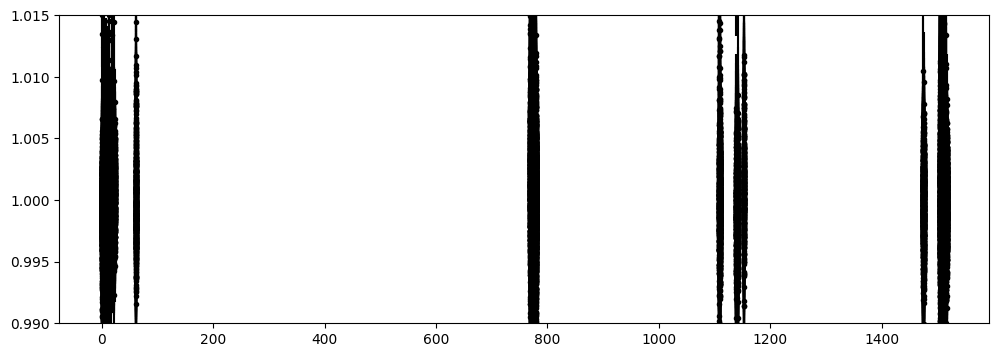

In [2]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
i = 1
file_to_use = all_files[1]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]
name = star_info['TARGET'].values[0]

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
# star_info

In [4]:
targ = LightCurve(name = name,
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun,
                           'Teff':T_star * u.K})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [5]:
targ

<🌟 Lightcurve file_018 (24546t) 🌟>

In [6]:
targ_with_transit = targ.inject_transit(per=2.55*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=1 * u.R_earth, 
                                        ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='transit_model'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

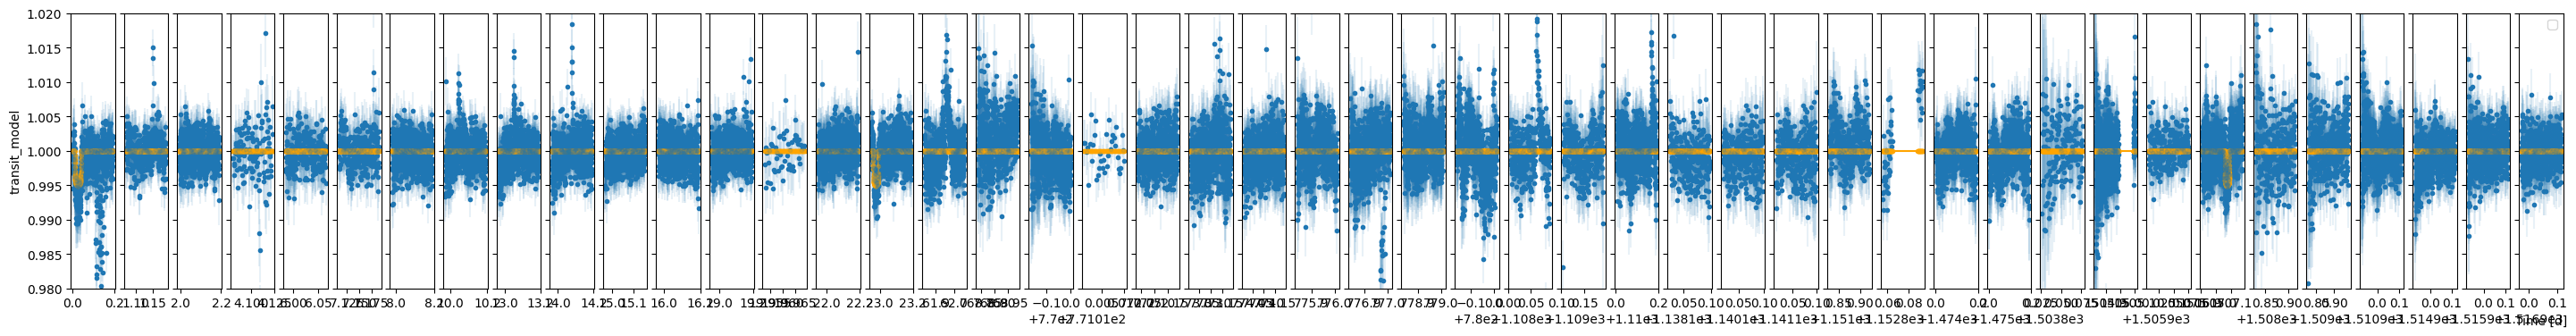

In [7]:
ax=targ_with_transit.plot()
targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")

In [8]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=rp, 
                                                          maximum_planet_radius=rp,
                                                          minimum_period=per, 
                                                          maximum_period=per,
                                                        )
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,0.40654,0.448629,0.00119,1.0,0.004288274427155711,0.032165,1.144004,3.763530784156991 solRad,26.882362743978504,0.0,...,0.0,0.0,0.0,0.0,0.0,file_018_inject,0.14 solRad,0.11 solMass,None,None


In [9]:
# lcs_with_transits, planets = targ.inject_lots_of_transits(nfake=10,
#                                                                   minimum_planet_radius=rp,
#                                                                   maximum_planet_radius=rp,
#                                                                   minimum_period=per,
#                                                                   maximum_period=10*u.d,
#                                                                   ld=ld,
#                                                           )

In [10]:
# lcs_with_transits

In [ ]:
x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=2,
                             minimum_planet_radius=4 * u.R_earth, 
                             maximum_planet_radius=5 * u.R_earth,
                             minimum_period=1 * u.d, 
                             maximum_period=3 * u.d, 
                             ld=[0.3,0.3],
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                         'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':True},
                             flare_kw = {'plot':True, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': True, 'verbose':True,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":None, "maximum_period":None, 'minimum_n_transit':2, 'obj':'snr',
                                      'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                      'verbose': True}, 
                            bls_bin=5 * u.minute,
                            recovery_kw = {'condition_on_epoch':1 * u.hour, 'min_n_transits': 1, 'meet_condition': 'any'},                           
                            verbose=True, plot=True, time_this_process=True,
                           plot_dir='../../Results/', save_plots=True, save_lcs=True,
                           plot_kw={'ylims':[0.98,1.02]})

1/2...
Saved LC as: ../../Results//0_file_018.pkl
Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...

            0.15073739102094028% of data is flagged as cosmics ⚡.
            
Saved LC as: ../../Results//0_file_018_inject0_clean.pkl
Time to clean LC: 10.28795599937439


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            There are 7 flare candidates with >30.0 s over 3$\sigma$
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved LC as: ../../Results//0_file_018_inject0_clean_sigmaclipped_flaresremoved.pkl
Time to remove flares: 30.891551971435547
Running BLS Search


In [ ]:
# time_to_clean = 19.79s -> now 10s
# time_to_remove_flares = 42.86s -> now 37.47s

In [10]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [22]:
lcs_bls[1]

[<🌟 Lightcurve secondLC_inject1_clean_sigmaclipped_flaresremoved_bin_bls_0 (302t) 🌟>]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


False


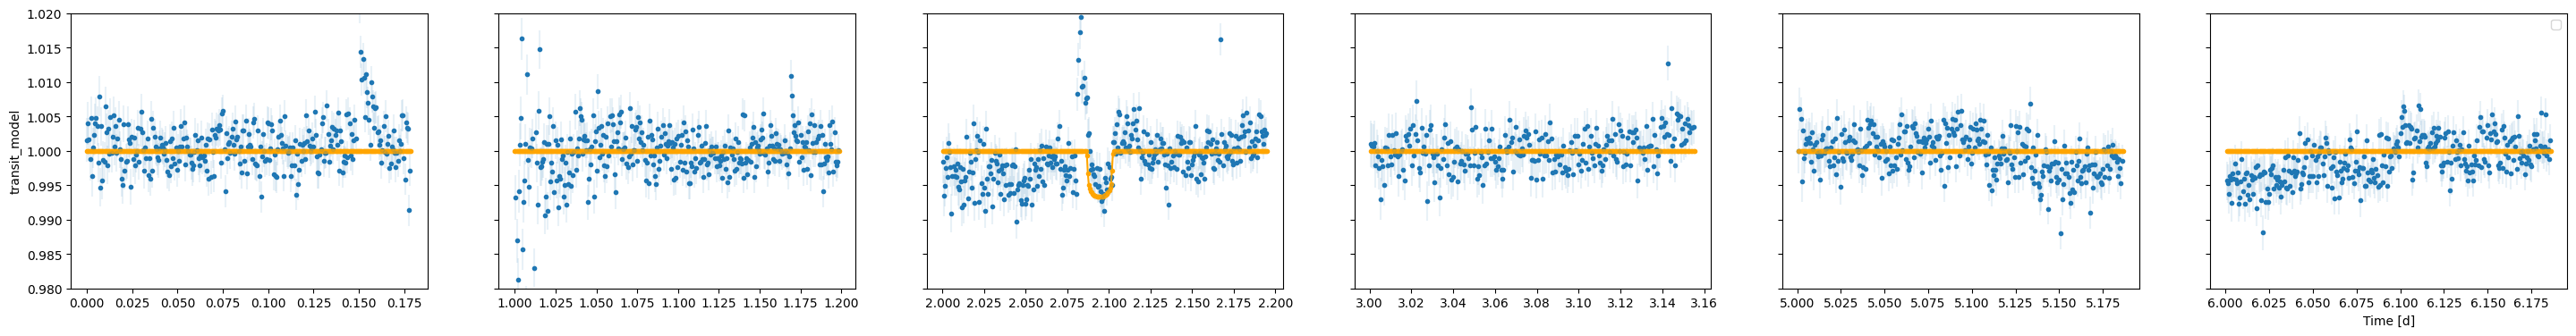

In [31]:
i=4
ax=lcs[i].plot()
lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
try:
    print(lcs_bls[i][0].metadata['BLS_transits_found'])
except:
    print(False)
    pass

In [45]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0    0.1 solRad
1    0.1 solRad
2    0.1 solRad
3    0.1 solRad
4    0.1 solRad
Name: r_s, dtype: object

Text(0.5, 0, 'Planet Radius [R_earth]')

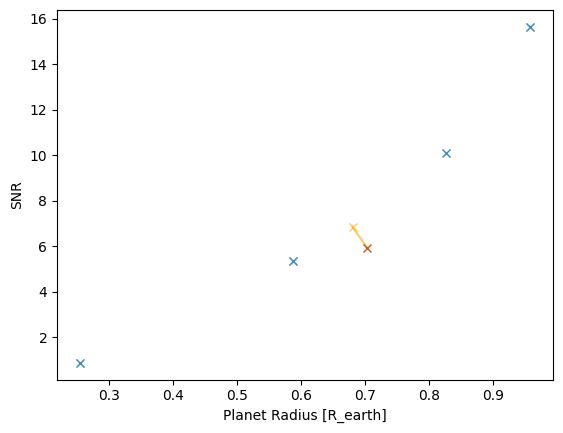

In [46]:
from astropy.units import Quantity

n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for r_p, depth, rec, r_p_rec, snr, n in zip(planets_df['r_p'], planets_df['depth'],  planets_df['recovered'],rec_r_p,  planets_df['snr'], n_points_in_transit):
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], 'x-', color=color, alpha=0.6)
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5)
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


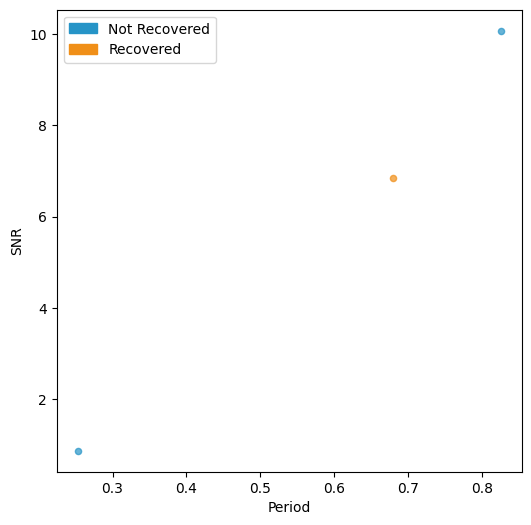

In [33]:
plot_transitparams(x=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Period", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=20,
                   svname="")